# HDF5 Spot Patch Augmentation

Create compact synthetic spot-overlap patches from confirmed isolated spots. Spots are paired only inside their own dataset/scan, so Aluminium and Iron are never mixed and separate scans stay separate. For each unordered spot pair, two random overlap samples are generated with random flips, arbitrary rotations, and a random requested overlap between 10% and 90%.


In [1]:
from pathlib import Path
import itertools
import json

import h5py
import hdf5plugin  # noqa: F401 - registers ESRF compression filters for h5py reads
import matplotlib.pyplot as plt
import numpy as np


def find_project_dir():
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if (candidate / "train.py").exists() and (candidate / "augment_data").exists():
            return candidate
    raise RuntimeError("Could not find project directory containing train.py and augment_data/.")


PROJECT_DIR = find_project_dir()
DATA_ESRF = PROJECT_DIR.parent / "data_esrf"
RAW_ROOTS = [DATA_ESRF, DATA_ESRF / "mnt"]

CATALOG_FILE = DATA_ESRF / "confirmed_spots_merged.h5"
if not CATALOG_FILE.exists():
    CATALOG_FILE = DATA_ESRF / "confirmed_spots_all.h5"

OUT_FILE = DATA_ESRF / "augmented_spot_patches.h5"
RAW_KEY = "instrument/detector_0/data"

PATCH_MARGIN = 8
FIXED_PATCH_SHAPE = (384, 384)  # fixed H, W so PyTorch/U-Net batches stack cleanly
RANDOM_PAIR_SAMPLES_PER_PAIR = 2
OVERLAP_RANGE = (0.10, 0.90)
INCLUDE_SINGLE_SPOT_VARIANTS = False
MAX_PAIR_SAMPLES_PER_DATASET = None  # set to an int for quick experiments
RNG_SEED = 7
OVERWRITE = False

print(f"Project dir : {PROJECT_DIR}")
print(f"Catalog     : {CATALOG_FILE}  exists={CATALOG_FILE.exists()}")
print(f"Output      : {OUT_FILE}")


Project dir : /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/Code
Catalog     : /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/data_esrf/confirmed_spots_merged.h5  exists=True
Output      : /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/data_esrf/augmented_spot_patches.h5


In [10]:
def material_from_scan(scan):
    # Examples: Al_small_grains -> Al, Al_big_grains -> Al, Ti7Al -> Ti7Al
    return str(scan).split("_")[0]


def dataset_exists(h5_file, key):
    try:
        with h5py.File(h5_file, "r") as f:
            return key in f and isinstance(f[key], h5py.Dataset)
    except OSError:
        return False


def first_3d_dataset(h5_file):
    found = []
    with h5py.File(h5_file, "r") as f:
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset) and obj.ndim >= 3:
                found.append(name)
        f.visititems(visitor)
    return found[0] if found else None


def find_scan_dir(scan):
    for root in RAW_ROOTS:
        scan_dir = root / scan
        if scan_dir.exists():
            return scan_dir
    raise FileNotFoundError(f"Could not find scan directory for {scan!r} in {RAW_ROOTS}")


def find_raw_file(scan):
    scan_dir = find_scan_dir(scan)
    h5_files = sorted(
        p for p in scan_dir.glob("*.h5")
        if p.name != "segvol.h5" and "dark" not in p.name.lower() and "confirmed" not in p.name.lower()
    )
    if not h5_files:
        raise FileNotFoundError(f"No raw .h5 file found in {scan_dir}")

    for h5_file in h5_files:
        if dataset_exists(h5_file, RAW_KEY):
            return h5_file, RAW_KEY

    for h5_file in h5_files:
        key = first_3d_dataset(h5_file)
        if key is not None:
            print(f"Using fallback raw dataset {key!r} in {h5_file.name} for scan {scan}")
            return h5_file, key

    raise FileNotFoundError(f"No 3D raw dataset found in {scan_dir}")


RAW_CACHE = {}


def raw_source(scan):
    if scan not in RAW_CACHE:
        RAW_CACHE[scan] = find_raw_file(scan)
    return RAW_CACHE[scan]


def load_raw_frame(scan, frame):
    raw_file, raw_key = raw_source(scan)
    with h5py.File(raw_file, "r") as f:
        data = f[raw_key]
        frame = int(frame) % data.shape[0]
        return np.asarray(data[frame])


In [11]:
def collect_spots(catalog_file):
    spots = []
    with h5py.File(catalog_file, "r") as f:
        def visitor(name, obj):
            if not isinstance(obj, h5py.Group) or "mask" not in obj or "bbox" not in obj:
                return
            scan = obj.attrs.get("scan", name.split("/")[0])
            frame = int(obj.attrs.get("frame"))
            blob_id = int(obj.attrs.get("blob_id", -1))
            bbox = np.asarray(obj["bbox"][()], dtype=np.int32)
            mask = np.asarray(obj["mask"][()], dtype=bool)
            if mask.sum() == 0:
                return
            spots.append({
                "name": name,
                "scan": str(scan),
                "dataset": str(scan),
                "material": material_from_scan(scan),
                "frame": frame,
                "blob_id": blob_id,
                "bbox": bbox,
                "mask": mask,
                "area_px": int(mask.sum()),
            })
        f.visititems(visitor)
    return spots


SPOTS = collect_spots(CATALOG_FILE)
BY_DATASET = {}
for spot in SPOTS:
    BY_DATASET.setdefault(spot["dataset"], []).append(spot)

print(f"Loaded {len(SPOTS)} confirmed spots")
for dataset, spots in sorted(BY_DATASET.items()):
    materials = sorted({s["material"] for s in spots})
    n_pairs = len(spots) * (len(spots) - 1) // 2
    n_random_pairs = n_pairs * RANDOM_PAIR_SAMPLES_PER_PAIR
    print(
        f"{dataset:<24} {len(spots):>4} spot(s), {n_pairs:>5} pair(s), "
        f"{n_random_pairs:>5} random pair sample(s), material={materials}"
    )


Loaded 75 confirmed spots
Al                         10 spot(s),    45 pair(s),    90 random pair sample(s), material=['Al']
Al_big_grains              10 spot(s),    45 pair(s),    90 random pair sample(s), material=['Al']
Al_small_grains            10 spot(s),    45 pair(s),    90 random pair sample(s), material=['Al']
Cu                         10 spot(s),    45 pair(s),    90 random pair sample(s), material=['Cu']
IN718_twins                10 spot(s),    45 pair(s),    90 random pair sample(s), material=['IN718']
Iron                       10 spot(s),    45 pair(s),    90 random pair sample(s), material=['Iron']
Iron_deformed               5 spot(s),    10 pair(s),    20 random pair sample(s), material=['Iron']
Ti7Al                      10 spot(s),    45 pair(s),    90 random pair sample(s), material=['Ti7Al']


In [12]:
print("Cell 5 loaded: random dataset-local pair overlap augmentation")


def tight_slices(mask, margin=0):
    rows, cols = np.where(mask)
    if rows.size == 0:
        raise ValueError("Cannot crop an empty mask")
    r0 = max(int(rows.min()) - margin, 0)
    c0 = max(int(cols.min()) - margin, 0)
    r1 = min(int(rows.max()) + margin + 1, mask.shape[0])
    c1 = min(int(cols.max()) + margin + 1, mask.shape[1])
    return slice(r0, r1), slice(c0, c1)


def bbox_crop_candidates(raw, bbox, mask_shape):
    a0, b0, a1, b1 = map(int, bbox)
    conventions = [
        ("row_col_exclusive", (a0, b0, a1, b1)),
        ("xy_exclusive", (b0, a0, b1, a1)),
        ("row_col_inclusive", (a0, b0, a1 + 1, b1 + 1)),
        ("xy_inclusive", (b0, a0, b1 + 1, a1 + 1)),
    ]

    seen = set()
    for name, (r0, c0, r1, c1) in conventions:
        key = (r0, c0, r1, c1)
        if key in seen:
            continue
        seen.add(key)
        if r0 < 0 or c0 < 0 or r1 > raw.shape[0] or c1 > raw.shape[1] or r1 <= r0 or c1 <= c0:
            continue

        crop = raw[r0:r1, c0:c1].astype(np.float32, copy=True)
        raw_bbox = [int(r0), int(c0), int(r1), int(c1)]
        if crop.shape == mask_shape:
            yield name, crop, raw_bbox
        if crop.T.shape == mask_shape:
            yield f"{name}_transposed", crop.T.copy(), raw_bbox


def rotate_image_and_mask(image, mask, angle_degrees):
    angle = np.deg2rad(angle_degrees)
    cos_a = float(np.cos(angle))
    sin_a = float(np.sin(angle))
    h, w = image.shape
    corners = np.array([
        [0, 0],
        [0, w - 1],
        [h - 1, 0],
        [h - 1, w - 1],
    ], dtype=np.float32)
    center = np.array([(h - 1) / 2.0, (w - 1) / 2.0], dtype=np.float32)
    rel = corners - center
    rotated = np.column_stack([
        rel[:, 0] * cos_a - rel[:, 1] * sin_a,
        rel[:, 0] * sin_a + rel[:, 1] * cos_a,
    ])
    min_rc = np.floor(rotated.min(axis=0))
    max_rc = np.ceil(rotated.max(axis=0))
    out_h = int(max_rc[0] - min_rc[0] + 1)
    out_w = int(max_rc[1] - min_rc[1] + 1)

    out_rows, out_cols = np.indices((out_h, out_w), dtype=np.float32)
    out_rel_r = out_rows + min_rc[0]
    out_rel_c = out_cols + min_rc[1]
    src_r = out_rel_r * cos_a + out_rel_c * sin_a + center[0]
    src_c = -out_rel_r * sin_a + out_rel_c * cos_a + center[1]

    nearest_r = np.rint(src_r).astype(np.int32)
    nearest_c = np.rint(src_c).astype(np.int32)
    valid_nearest = (nearest_r >= 0) & (nearest_r < h) & (nearest_c >= 0) & (nearest_c < w)
    rotated_mask = np.zeros((out_h, out_w), dtype=bool)
    rotated_mask[valid_nearest] = mask[nearest_r[valid_nearest], nearest_c[valid_nearest]]

    r0 = np.floor(src_r).astype(np.int32)
    c0 = np.floor(src_c).astype(np.int32)
    r1 = r0 + 1
    c1 = c0 + 1
    valid_linear = (r0 >= 0) & (r1 < h) & (c0 >= 0) & (c1 < w)
    rotated_image = np.zeros((out_h, out_w), dtype=np.float32)
    dr = src_r - r0
    dc = src_c - c0
    rotated_image[valid_linear] = (
        image[r0[valid_linear], c0[valid_linear]] * (1 - dr[valid_linear]) * (1 - dc[valid_linear])
        + image[r1[valid_linear], c0[valid_linear]] * dr[valid_linear] * (1 - dc[valid_linear])
        + image[r0[valid_linear], c1[valid_linear]] * (1 - dr[valid_linear]) * dc[valid_linear]
        + image[r1[valid_linear], c1[valid_linear]] * dr[valid_linear] * dc[valid_linear]
    )
    return rotated_image, rotated_mask


def crop_spot_signal(spot, margin=PATCH_MARGIN):
    raw = load_raw_frame(spot["scan"], spot["frame"]).astype(np.float32, copy=False)
    mask = spot["mask"].astype(bool, copy=False)

    candidates = list(bbox_crop_candidates(raw, spot["bbox"], mask.shape))
    if not candidates:
        raise ValueError(
            f"Could not align raw crop and mask for {spot['name']}: "
            f"bbox={spot['bbox'].tolist()}, raw frame shape={raw.shape}, mask shape={mask.shape}"
        )

    bbox_convention, crop, raw_bbox = candidates[0]
    if crop.shape != mask.shape:
        raise RuntimeError(f"Internal crop alignment failed for {spot['name']}: crop {crop.shape}, mask {mask.shape}")
    if len(candidates) > 1:
        preferred = [candidate for candidate in candidates if "transposed" not in candidate[0]]
        if preferred:
            bbox_convention, crop, raw_bbox = preferred[0]

    background_pixels = crop[~mask]
    if background_pixels.size:
        local_background = float(np.median(background_pixels))
    else:
        local_background = float(np.percentile(crop, 10))

    signal = crop - local_background
    signal[~mask] = 0.0
    signal[signal < 0] = 0.0

    rr, cc = tight_slices(mask, margin=margin)
    metadata = {
        "bbox_convention": bbox_convention,
        "raw_bbox": raw_bbox,
    }
    return signal[rr, cc], mask[rr, cc], metadata


def random_spot_variant(spot, rng, allow_flip=True, angle_range=(0.0, 360.0)):
    signal, mask, crop_meta = crop_spot_signal(spot)
    flip_ud = bool(allow_flip and rng.integers(0, 2))
    flip_lr = bool(allow_flip and rng.integers(0, 2))
    angle = float(rng.uniform(*angle_range))

    if flip_ud:
        signal = np.flipud(signal)
        mask = np.flipud(mask)
    if flip_lr:
        signal = np.fliplr(signal)
        mask = np.fliplr(mask)

    rotated_signal, rotated_mask = rotate_image_and_mask(signal, mask, angle)

    if rotated_mask.any():
        rr, cc = tight_slices(rotated_mask, margin=0)
        rotated_signal = rotated_signal[rr, cc]
        rotated_mask = rotated_mask[rr, cc]

    rotated_signal = np.asarray(rotated_signal, dtype=np.float32)
    rotated_signal[~rotated_mask] = 0.0
    return {
        "spot": spot,
        "variant": "random_flip_rotate",
        "image": np.ascontiguousarray(rotated_signal),
        "mask": np.ascontiguousarray(rotated_mask, dtype=bool),
        "crop_meta": crop_meta,
        "flip_ud": flip_ud,
        "flip_lr": flip_lr,
        "angle_degrees": angle,
    }


def paste_variant(image, mask, variant, top, left, spot_mask=None):
    patch = variant["image"]
    patch_mask = variant["mask"]
    h, w = patch.shape
    bottom = top + h
    right = left + w
    if top < 0 or left < 0 or bottom > image.shape[0] or right > image.shape[1]:
        raise ValueError(
            f"Patch does not fit canvas: patch={patch.shape}, top/left={(top, left)}, "
            f"canvas={image.shape}, spot={variant['spot']['name']}, variant={variant['variant']}"
        )
    region = image[top:bottom, left:right]
    region_mask = mask[top:bottom, left:right]
    region[patch_mask] += patch[patch_mask]
    region_mask[patch_mask] = 1
    if spot_mask is not None:
        spot_mask[top:bottom, left:right][patch_mask] = 1
    return [int(top), int(left), int(bottom), int(right)]


def variant_metadata(variant, paste_bbox):
    spot = variant["spot"]
    return {
        "spot": spot["name"],
        "scan": spot["scan"],
        "dataset": spot["dataset"],
        "frame": int(spot["frame"]),
        "blob_id": int(spot["blob_id"]),
        "source_bbox": [int(x) for x in spot["bbox"]],
        "raw_bbox": variant["crop_meta"]["raw_bbox"],
        "bbox_convention": variant["crop_meta"]["bbox_convention"],
        "variant": variant["variant"],
        "flip_ud": bool(variant.get("flip_ud", False)),
        "flip_lr": bool(variant.get("flip_lr", False)),
        "angle_degrees": float(variant.get("angle_degrees", 0.0)),
        "paste_bbox": paste_bbox,
    }


def make_single_sample(variant):
    h, w = variant["mask"].shape
    image = np.zeros((h, w), dtype=np.float32)
    mask = np.zeros((h, w), dtype=np.uint8)
    spot_masks = np.zeros((1, h, w), dtype=np.uint8)
    bbox = paste_variant(image, mask, variant, 0, 0, spot_mask=spot_masks[0])
    spot = variant["spot"]
    metadata = {
        "kind": "single",
        "dataset": spot["dataset"],
        "material": spot["material"],
        "donor_spots": [variant_metadata(variant, bbox)],
    }
    return finalize_sample(image, mask, metadata, spot_masks=spot_masks)


def mask_overlap_for_offset(left_mask, right_mask, right_top, right_left):
    lh, lw = left_mask.shape
    rh, rw = right_mask.shape
    left_r0 = max(0, right_top)
    left_c0 = max(0, right_left)
    left_r1 = min(lh, right_top + rh)
    left_c1 = min(lw, right_left + rw)
    if left_r1 <= left_r0 or left_c1 <= left_c0:
        return 0.0

    right_r0 = left_r0 - right_top
    right_c0 = left_c0 - right_left
    right_r1 = right_r0 + (left_r1 - left_r0)
    right_c1 = right_c0 + (left_c1 - left_c0)
    overlap_px = np.logical_and(
        left_mask[left_r0:left_r1, left_c0:left_c1],
        right_mask[right_r0:right_r1, right_c0:right_c1],
    ).sum()
    smaller_area = min(int(left_mask.sum()), int(right_mask.sum()))
    if smaller_area == 0:
        return 0.0
    return float(overlap_px / smaller_area)


def positive_canvas_layout(left_shape, right_shape, right_top, right_left):
    lh, lw = left_shape
    rh, rw = right_shape
    top0 = min(0, right_top)
    left0 = min(0, right_left)
    left_top = -top0
    left_left = -left0
    right_top = right_top - top0
    right_left = right_left - left0
    canvas_h = max(left_top + lh, right_top + rh)
    canvas_w = max(left_left + lw, right_left + rw)
    return int(left_top), int(left_left), int(right_top), int(right_left), int(canvas_h), int(canvas_w)


def random_pair_layout(left_mask, right_mask, requested_overlap, rng, attempts=256):
    lh, lw = left_mask.shape
    rh, rw = right_mask.shape
    requested_overlap = float(np.clip(requested_overlap, *OVERLAP_RANGE))

    bbox_overlap_h = max(1, int(round(min(lh, rh) * requested_overlap)))
    bbox_overlap_w = max(1, int(round(min(lw, rw) * requested_overlap)))
    seeded_offsets = [
        (lh - bbox_overlap_h, lw - bbox_overlap_w),
        (lh - bbox_overlap_h, -(rw - bbox_overlap_w)),
        (-(rh - bbox_overlap_h), lw - bbox_overlap_w),
        (-(rh - bbox_overlap_h), -(rw - bbox_overlap_w)),
        ((lh - rh) // 2, (lw - rw) // 2),
    ]

    candidates = []
    for right_top, right_left in seeded_offsets:
        candidates.append((int(right_top), int(right_left)))

    min_top = -rh + 1
    max_top = lh - 1
    min_left = -rw + 1
    max_left = lw - 1
    for _ in range(attempts):
        candidates.append((
            int(rng.integers(min_top, max_top + 1)),
            int(rng.integers(min_left, max_left + 1)),
        ))

    best = None
    for right_top, right_left in candidates:
        measured = mask_overlap_for_offset(left_mask, right_mask, right_top, right_left)
        inside_range_penalty = 0.0 if OVERLAP_RANGE[0] <= measured <= OVERLAP_RANGE[1] else 1.0
        score = (inside_range_penalty, abs(measured - requested_overlap), -measured)
        if best is None or score < best[0]:
            best = (score, right_top, right_left, measured)

    _, right_top, right_left, measured = best
    layout = positive_canvas_layout(left_mask.shape, right_mask.shape, right_top, right_left)
    return (*layout, float(measured))


def measured_mask_overlap_fraction(left_mask, right_mask, left_top, left_left, right_top, right_left, canvas_shape):
    left_canvas = np.zeros(canvas_shape, dtype=bool)
    right_canvas = np.zeros(canvas_shape, dtype=bool)
    lh, lw = left_mask.shape
    rh, rw = right_mask.shape
    left_canvas[left_top:left_top + lh, left_left:left_left + lw] = left_mask
    right_canvas[right_top:right_top + rh, right_left:right_left + rw] = right_mask
    smaller_area = min(int(left_mask.sum()), int(right_mask.sum()))
    if smaller_area == 0:
        return 0.0
    return float(np.logical_and(left_canvas, right_canvas).sum() / smaller_area)


def fit_sample_to_fixed_shape(image, mask, spot_masks=None, target_shape=FIXED_PATCH_SHAPE):
    target_h, target_w = map(int, target_shape)
    h, w = image.shape
    crop_top = max(0, (h - target_h) // 2)
    crop_left = max(0, (w - target_w) // 2)
    crop_bottom = min(h, crop_top + target_h)
    crop_right = min(w, crop_left + target_w)

    cropped_image = image[crop_top:crop_bottom, crop_left:crop_right]
    cropped_mask = mask[crop_top:crop_bottom, crop_left:crop_right]
    if spot_masks is not None:
        cropped_spot_masks = spot_masks[:, crop_top:crop_bottom, crop_left:crop_right]
    else:
        cropped_spot_masks = None

    out_image = np.zeros((target_h, target_w), dtype=np.float32)
    out_mask = np.zeros((target_h, target_w), dtype=np.uint8)
    out_spot_masks = None
    if cropped_spot_masks is not None:
        out_spot_masks = np.zeros((cropped_spot_masks.shape[0], target_h, target_w), dtype=np.uint8)

    paste_top = max(0, (target_h - cropped_image.shape[0]) // 2)
    paste_left = max(0, (target_w - cropped_image.shape[1]) // 2)
    paste_bottom = paste_top + cropped_image.shape[0]
    paste_right = paste_left + cropped_image.shape[1]

    out_image[paste_top:paste_bottom, paste_left:paste_right] = cropped_image
    out_mask[paste_top:paste_bottom, paste_left:paste_right] = cropped_mask
    if out_spot_masks is not None:
        out_spot_masks[:, paste_top:paste_bottom, paste_left:paste_right] = cropped_spot_masks

    transform = {
        "original_shape": [int(h), int(w)],
        "fixed_shape": [int(target_h), int(target_w)],
        "crop_bbox": [int(crop_top), int(crop_left), int(crop_bottom), int(crop_right)],
        "pad_top_left": [int(paste_top), int(paste_left)],
        "cropped_to_fit": bool(h > target_h or w > target_w),
    }
    bbox_shift = [int(paste_top - crop_top), int(paste_left - crop_left)]
    return out_image, out_mask, out_spot_masks, transform, bbox_shift


def shift_bbox(bbox, row_shift, col_shift, shape):
    h, w = shape
    r0, c0, r1, c1 = bbox
    return [
        int(np.clip(r0 + row_shift, 0, h)),
        int(np.clip(c0 + col_shift, 0, w)),
        int(np.clip(r1 + row_shift, 0, h)),
        int(np.clip(c1 + col_shift, 0, w)),
    ]


def finalize_sample(image, mask, metadata, spot_masks=None, target_shape=FIXED_PATCH_SHAPE):
    image, mask, spot_masks, transform, bbox_shift = fit_sample_to_fixed_shape(image, mask, spot_masks, target_shape)
    metadata = dict(metadata)
    metadata["fixed_patch"] = transform
    for donor in metadata.get("donor_spots", []):
        donor["paste_bbox_original_canvas"] = donor["paste_bbox"]
        donor["paste_bbox"] = shift_bbox(donor["paste_bbox"], bbox_shift[0], bbox_shift[1], image.shape)
    if spot_masks is not None:
        mask = (spot_masks.sum(axis=0) > 0).astype(np.uint8)
    return image, mask.astype(np.uint8), metadata, spot_masks


def make_random_pair_sample(left_spot, right_spot, rng):
    if left_spot["dataset"] != right_spot["dataset"]:
        raise ValueError(f"Refusing to mix datasets: {left_spot['dataset']} vs {right_spot['dataset']}")
    if left_spot["material"] != right_spot["material"]:
        raise ValueError(f"Refusing to mix materials: {left_spot['material']} vs {right_spot['material']}")

    left_variant = random_spot_variant(left_spot, rng)
    right_variant = random_spot_variant(right_spot, rng)
    requested_overlap = float(rng.uniform(*OVERLAP_RANGE))

    layout = random_pair_layout(left_variant["mask"], right_variant["mask"], requested_overlap, rng)
    left_top, left_left, right_top, right_left, canvas_h, canvas_w, measured_overlap = layout
    image = np.zeros((canvas_h, canvas_w), dtype=np.float32)
    mask = np.zeros((canvas_h, canvas_w), dtype=np.uint8)
    spot_masks = np.zeros((2, canvas_h, canvas_w), dtype=np.uint8)

    left_bbox = paste_variant(image, mask, left_variant, left_top, left_left, spot_mask=spot_masks[0])
    right_bbox = paste_variant(image, mask, right_variant, right_top, right_left, spot_mask=spot_masks[1])
    metadata = {
        "kind": "pair_overlap",
        "dataset": left_spot["dataset"],
        "material": left_spot["material"],
        "requested_overlap_fraction": requested_overlap,
        "measured_mask_overlap_fraction": measured_overlap,
        "donor_spots": [
            variant_metadata(left_variant, left_bbox),
            variant_metadata(right_variant, right_bbox),
        ],
    }
    return finalize_sample(image, mask, metadata, spot_masks=spot_masks)


def generate_random_overlap_samples(seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    for dataset, spots in sorted(BY_DATASET.items()):
        if INCLUDE_SINGLE_SPOT_VARIANTS:
            for spot in spots:
                yield dataset, make_single_sample(random_spot_variant(spot, rng))

        pair_iter = itertools.combinations(spots, 2)
        if MAX_PAIR_SAMPLES_PER_DATASET is not None:
            pair_iter = itertools.islice(pair_iter, MAX_PAIR_SAMPLES_PER_DATASET)

        for left_spot, right_spot in pair_iter:
            for repeat in range(RANDOM_PAIR_SAMPLES_PER_PAIR):
                image, mask, metadata, spot_masks = make_random_pair_sample(left_spot, right_spot, rng)
                metadata["pair_repeat"] = int(repeat)
                yield dataset, (image, mask, metadata, spot_masks)


def generate_samples(seed=RNG_SEED):
    yield from generate_random_overlap_samples(seed=seed)


Cell 5 loaded: random dataset-local pair overlap augmentation


{
  "kind": "pair_overlap",
  "dataset": "Al",
  "material": "Al",
  "requested_overlap_fraction": 0.34013302792898037,
  "measured_mask_overlap_fraction": 0.3368327402135231,
  "donor_spots": [
    {
      "spot": "Al/frame_1200_blob_0128",
      "scan": "Al",
      "dataset": "Al",
      "frame": 1200,
      "blob_id": 128,
      "source_bbox": [
        1627,
        1404,
        1745,
        1526
      ],
      "raw_bbox": [
        1627,
        1404,
        1745,
        1526
      ],
      "bbox_convention": "row_col_exclusive",
      "variant": "random_flip_rotate",
      "flip_ud": true,
      "flip_lr": true,
      "angle_degrees": 322.99696834904717,
      "paste_bbox": [
        188,
        131,
        288,
        212
      ],
      "paste_bbox_original_canvas": [
        93,
        7,
        193,
        88
      ]
    },
    {
      "spot": "Al/frame_1201_blob_0066",
      "scan": "Al",
      "dataset": "Al",
      "frame": 1201,
      "blob_id": 66,
      "source

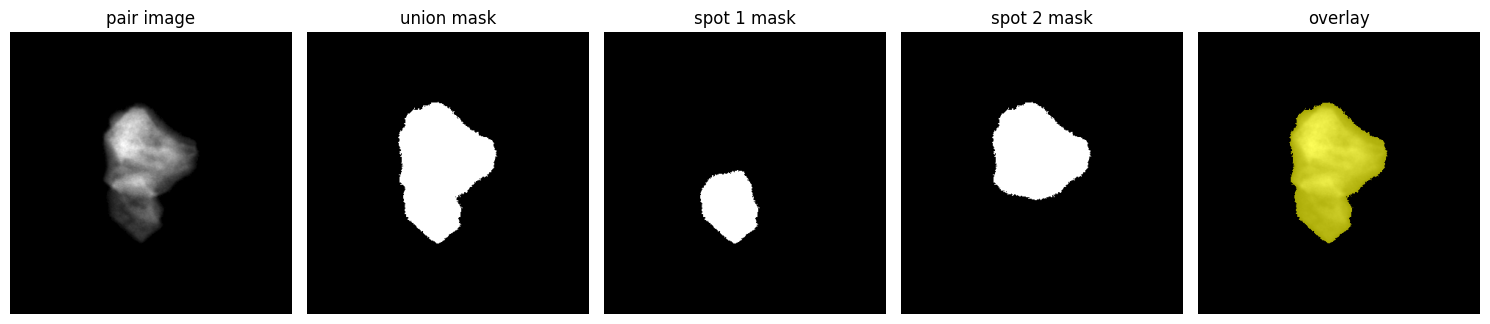

In [13]:
# Visual sanity check: one synthetic overlapping pair patch.
preview_iter = generate_random_overlap_samples(seed=RNG_SEED)
preview_pair = None
for _, sample in preview_iter:
    image, mask, meta, spot_masks = sample
    if meta["kind"] == "pair_overlap":
        preview_pair = sample
        break

if preview_pair is None:
    raise RuntimeError("No pair preview could be generated. Check that at least one dataset has two spots.")

image, mask, meta, spot_masks = preview_pair
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
axes[0].imshow(image, cmap="gray")
axes[0].set_title("pair image")
axes[1].imshow(mask, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("union mask")
axes[2].imshow(spot_masks[0], cmap="gray", vmin=0, vmax=1)
axes[2].set_title("spot 1 mask")
axes[3].imshow(spot_masks[1], cmap="gray", vmin=0, vmax=1)
axes[3].set_title("spot 2 mask")
axes[4].imshow(image, cmap="gray")
axes[4].imshow(np.ma.masked_where(mask == 0, mask), cmap="autumn", alpha=0.65, vmin=0, vmax=1)
axes[4].set_title("overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
print(json.dumps(meta, indent=2))


Showing 5 sample(s), start=0, next start=5


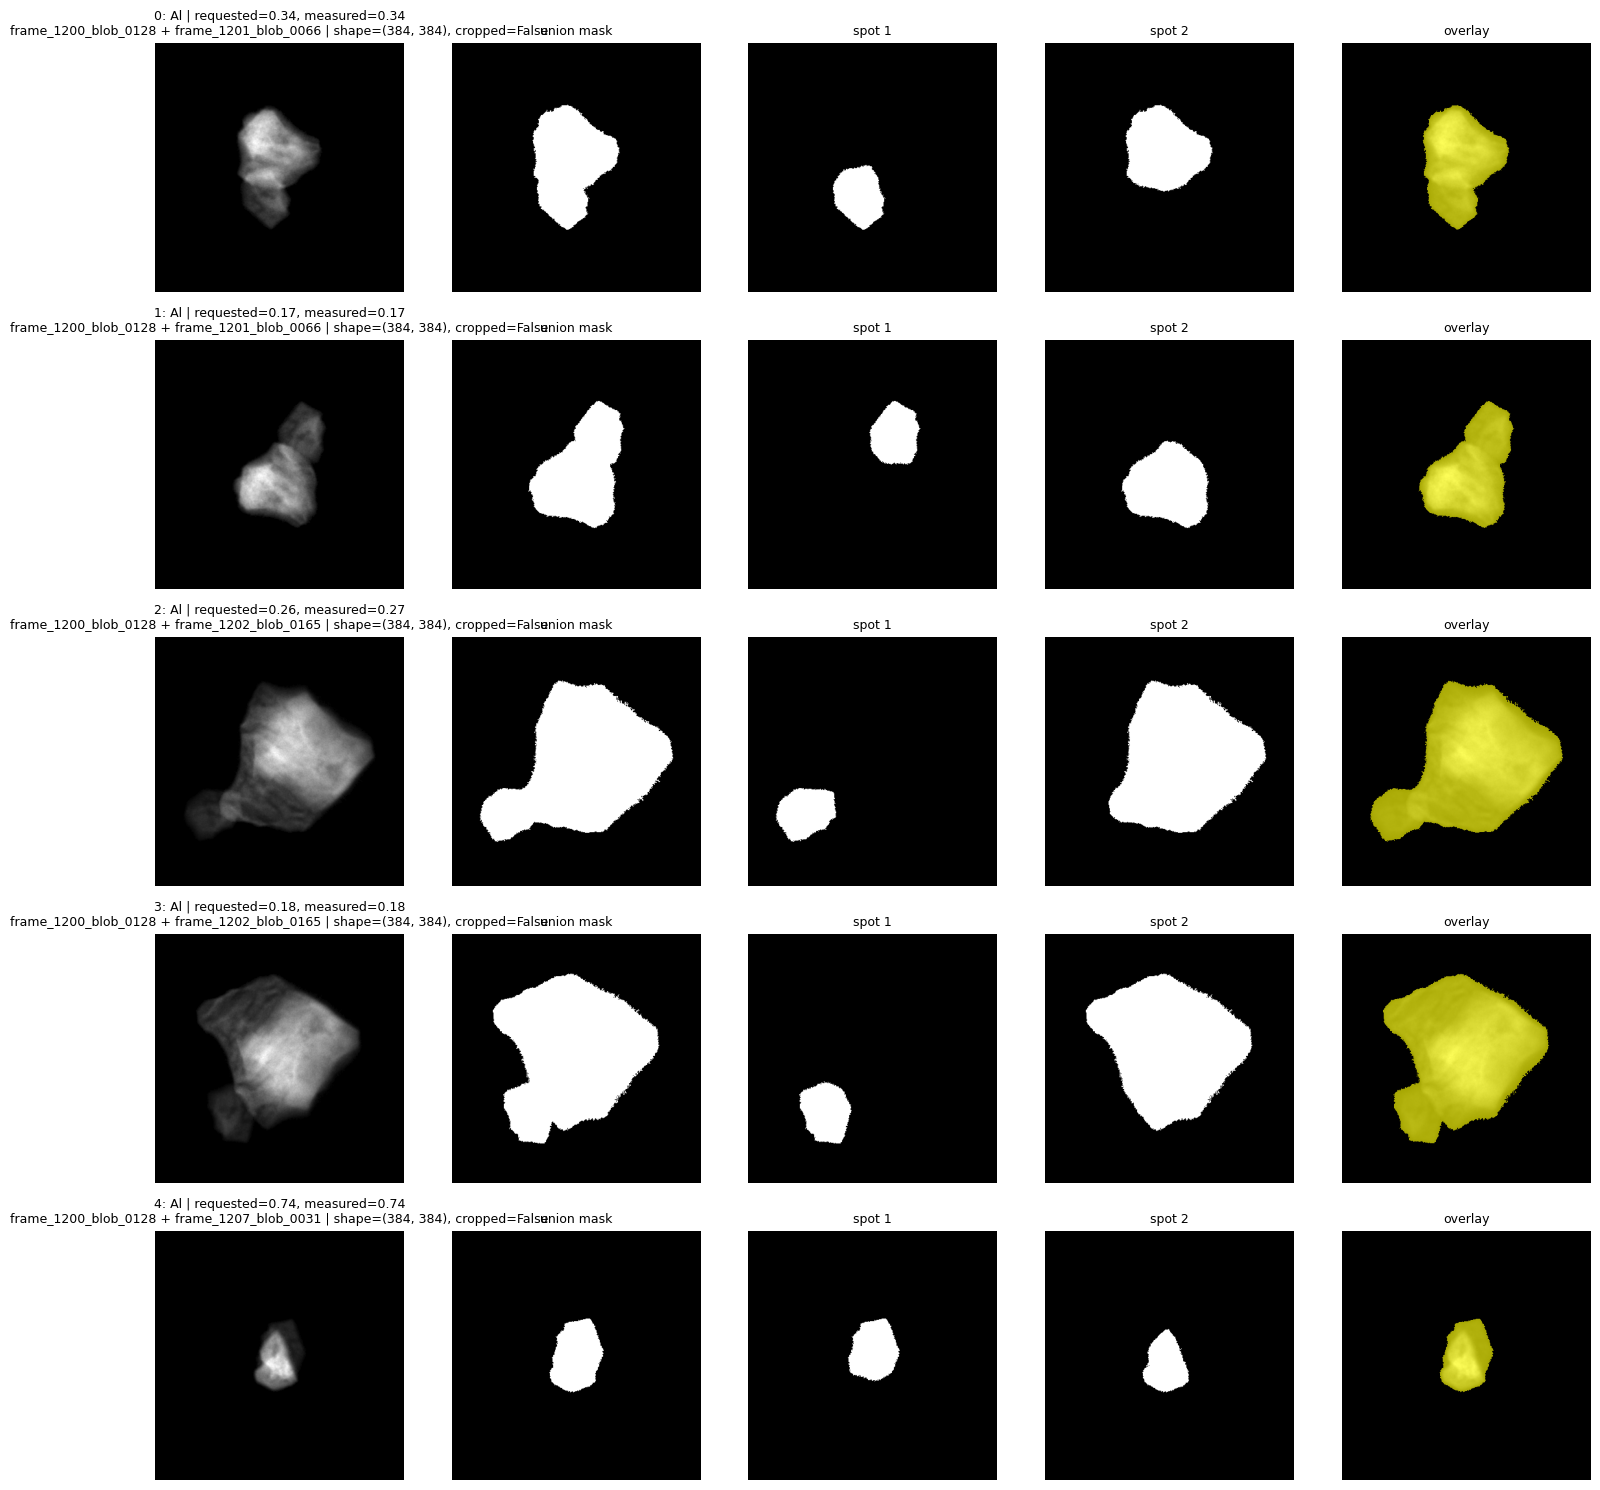

In [14]:
def browse_random_overlap_samples(start=0, count=5, dataset=None, seed=RNG_SEED):
    shown = []
    skipped = 0
    for sample_dataset, sample in generate_random_overlap_samples(seed=seed):
        if dataset is not None and sample_dataset != dataset:
            continue
        if skipped < start:
            skipped += 1
            continue
        shown.append((sample_dataset, sample))
        if len(shown) >= count:
            break

    if not shown:
        print("No samples found. Check start/count or dataset name.")
        return

    fig, axes = plt.subplots(len(shown), 5, figsize=(15, 3 * len(shown)), squeeze=False)
    for row, (sample_dataset, sample) in enumerate(shown):
        image, mask, meta, spot_masks = sample
        requested = meta.get("requested_overlap_fraction", 0.0)
        measured = meta.get("measured_mask_overlap_fraction", 0.0)
        donors = [donor["spot"].split("/")[-1] for donor in meta["donor_spots"]]
        fixed = meta.get("fixed_patch", {})
        title = (
            f"{start + row}: {sample_dataset} | requested={requested:.2f}, measured={measured:.2f}\n"
            f"{donors[0]} + {donors[1]} | shape={image.shape}, cropped={fixed.get('cropped_to_fit', False)}"
        )

        axes[row, 0].imshow(image, cmap="gray")
        axes[row, 0].set_title(title, fontsize=9)
        axes[row, 1].imshow(mask, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title("union mask", fontsize=9)
        axes[row, 2].imshow(spot_masks[0], cmap="gray", vmin=0, vmax=1)
        axes[row, 2].set_title("spot 1", fontsize=9)
        axes[row, 3].imshow(spot_masks[1], cmap="gray", vmin=0, vmax=1)
        axes[row, 3].set_title("spot 2", fontsize=9)
        axes[row, 4].imshow(image, cmap="gray")
        axes[row, 4].imshow(np.ma.masked_where(mask == 0, mask), cmap="autumn", alpha=0.65, vmin=0, vmax=1)
        axes[row, 4].set_title("overlay", fontsize=9)
        for ax in axes[row]:
            ax.axis("off")

    plt.tight_layout()
    print(f"Showing {len(shown)} sample(s), start={start}, next start={start + len(shown)}")


# Change start to browse the next batch: 0, 5, 10, ...
# Set dataset="Iron" or dataset="Al" if you only want one dataset.
browse_random_overlap_samples(start=0, count=5, dataset=None, seed=RNG_SEED)


In [16]:
def write_augmented_archive(out_file=OUT_FILE, seed=RNG_SEED, overwrite=OVERWRITE):
    out_file = Path(out_file)
    if out_file.exists() and not overwrite:
        raise FileExistsError(f"{out_file} already exists. Set OVERWRITE = True if you want to replace it.")
    if out_file.exists() and overwrite:
        out_file.unlink()

    sample_count = 0
    per_dataset = {dataset: 0 for dataset in BY_DATASET}
    cropped_count = 0
    with h5py.File(out_file, "w") as f:
        f.attrs["source_catalog"] = str(CATALOG_FILE)
        f.attrs["seed"] = int(seed)
        f.attrs["target"] = "binary_spot_patch_segmentation_with_aligned_donor_masks"
        f.attrs["augmentation"] = "dataset-local unordered pairs; two random flip/rotation/overlap samples per pair"
        f.attrs["patch_margin"] = int(PATCH_MARGIN)
        f.attrs["fixed_patch_shape"] = json.dumps([int(x) for x in FIXED_PATCH_SHAPE])
        f.attrs["include_single_spot_variants"] = bool(INCLUDE_SINGLE_SPOT_VARIANTS)
        f.attrs["random_pair_samples_per_pair"] = int(RANDOM_PAIR_SAMPLES_PER_PAIR)
        f.attrs["overlap_range"] = json.dumps([float(x) for x in OVERLAP_RANGE])
        f.attrs["datasets"] = json.dumps(sorted(BY_DATASET))

        for dataset, (image, mask, metadata, spot_masks) in generate_samples(seed=seed):
            group = f.create_group(f"sample_{sample_count:06d}")
            group.create_dataset("image", data=image.astype(np.float32), compression="gzip")
            group.create_dataset("mask", data=mask.astype(np.uint8), compression="gzip")
            group.create_dataset("spot_masks", data=spot_masks.astype(np.uint8), compression="gzip")
            group.attrs["dataset"] = metadata["dataset"]
            group.attrs["material"] = metadata["material"]
            group.attrs["kind"] = metadata["kind"]
            group.attrs["requested_overlap_fraction"] = float(metadata.get("requested_overlap_fraction", 0.0))
            group.attrs["measured_mask_overlap_fraction"] = float(metadata.get("measured_mask_overlap_fraction", 0.0))
            group.attrs["donor_spots"] = json.dumps(metadata["donor_spots"])
            group.attrs["paste_positions"] = json.dumps([p["paste_bbox"] for p in metadata["donor_spots"]])
            group.attrs["fixed_patch"] = json.dumps(metadata.get("fixed_patch", {}))
            cropped_count += int(metadata.get("fixed_patch", {}).get("cropped_to_fit", False))
            sample_count += 1
            per_dataset[dataset] += 1

    print(f"Wrote {sample_count} sample(s) to {out_file}")
    print(f"Fixed patch shape: {FIXED_PATCH_SHAPE}; cropped-to-fit sample(s): {cropped_count}")
    for dataset, count in sorted(per_dataset.items()):
        print(f"{dataset:<24} {count:>6} sample(s)")


# Uncomment after the preview looks sensible.
write_augmented_archive()


OSError: Unable to synchronously open file (truncated file: eof = 824442880, sblock->base_addr = 0, stored_eof = 21793451465)

In [8]:
def validate_archive(path=OUT_FILE):
    path = Path(path)
    if not path.exists():
        print(f"No archive yet: {path}")
        return

    problems = []
    with h5py.File(path, "r") as f:
        sample_names = sorted(k for k, v in f.items() if isinstance(v, h5py.Group))
        expected_shape = tuple(json.loads(f.attrs.get("fixed_patch_shape", "[]")))
        for name in sample_names:
            group = f[name]
            image = group["image"]
            mask = group["mask"]
            spot_masks = group.get("spot_masks")
            if image.shape != mask.shape:
                problems.append(f"{name}: image shape {image.shape} != mask shape {mask.shape}")
            if expected_shape and image.shape != expected_shape:
                problems.append(f"{name}: image shape {image.shape} != fixed shape {expected_shape}")
            if spot_masks is None:
                problems.append(f"{name}: missing spot_masks dataset")
            elif spot_masks.shape[1:] != image.shape:
                problems.append(f"{name}: spot_masks shape {spot_masks.shape} does not align with image {image.shape}")
            elif not np.array_equal((spot_masks[()].sum(axis=0) > 0).astype(np.uint8), mask[()]):
                problems.append(f"{name}: union mask does not match spot_masks union")
            values = np.unique(mask[()])
            if not set(values.tolist()).issubset({0, 1}):
                problems.append(f"{name}: mask values are {values}")
            dataset = group.attrs["dataset"]
            material = group.attrs["material"]
            donors = json.loads(group.attrs["donor_spots"])
            for donor in donors:
                if donor["dataset"] != dataset:
                    problems.append(f"{name}: donor dataset mismatch {donor}")
                if material_from_scan(donor["scan"]) != material:
                    problems.append(f"{name}: donor material mismatch {donor}")
                r0, c0, r1, c1 = donor["paste_bbox"]
                h, w = image.shape
                if r0 < 0 or c0 < 0 or r1 > h or c1 > w:
                    problems.append(f"{name}: paste bbox out of bounds {donor['paste_bbox']} for shape {image.shape}")

    if problems:
        print("Validation problems:")
        for problem in problems[:20]:
            print(" -", problem)
        if len(problems) > 20:
            print(f" ... {len(problems) - 20} more")
    else:
        print(f"Archive looks OK: {len(sample_names)} sample(s)")


# validate_archive()


File: /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/data_esrf/augmented_spot_patches.h5
Samples: 560
Attributes:
  augmentation: dataset-local unordered pairs; two random flip/rotation/overlap samples per pair
  datasets: ["Al", "Al_big_grains", "Al_small_grains", "Cu", "IN718_twins", "Iron", "Iron_deformed", "Ti7Al"]
  fixed_patch_shape: [384, 384]
  include_single_spot_variants: False
  overlap_range: [0.1, 0.9]
  patch_margin: 8
  random_pair_samples_per_pair: 2
  seed: 7
  source_catalog: /var/home/natalieboehm/Documents/Studium/Master/Masterarbeit/data_esrf/confirmed_spots_merged.h5
  target: binary_spot_patch_segmentation_with_aligned_donor_masks
By dataset:
  Al: 90
  Al_big_grains: 90
  Al_small_grains: 90
  Cu: 90
  IN718_twins: 90
  Iron: 90
  Iron_deformed: 20
By kind:
  pair_overlap: 560
Most common image shapes:
  (384, 384): 560
Spot-mask storage:
  (2, 384, 384): 560
Cropped-to-fit samples: 0
Showing 5 saved sample(s), start=0, next start=5


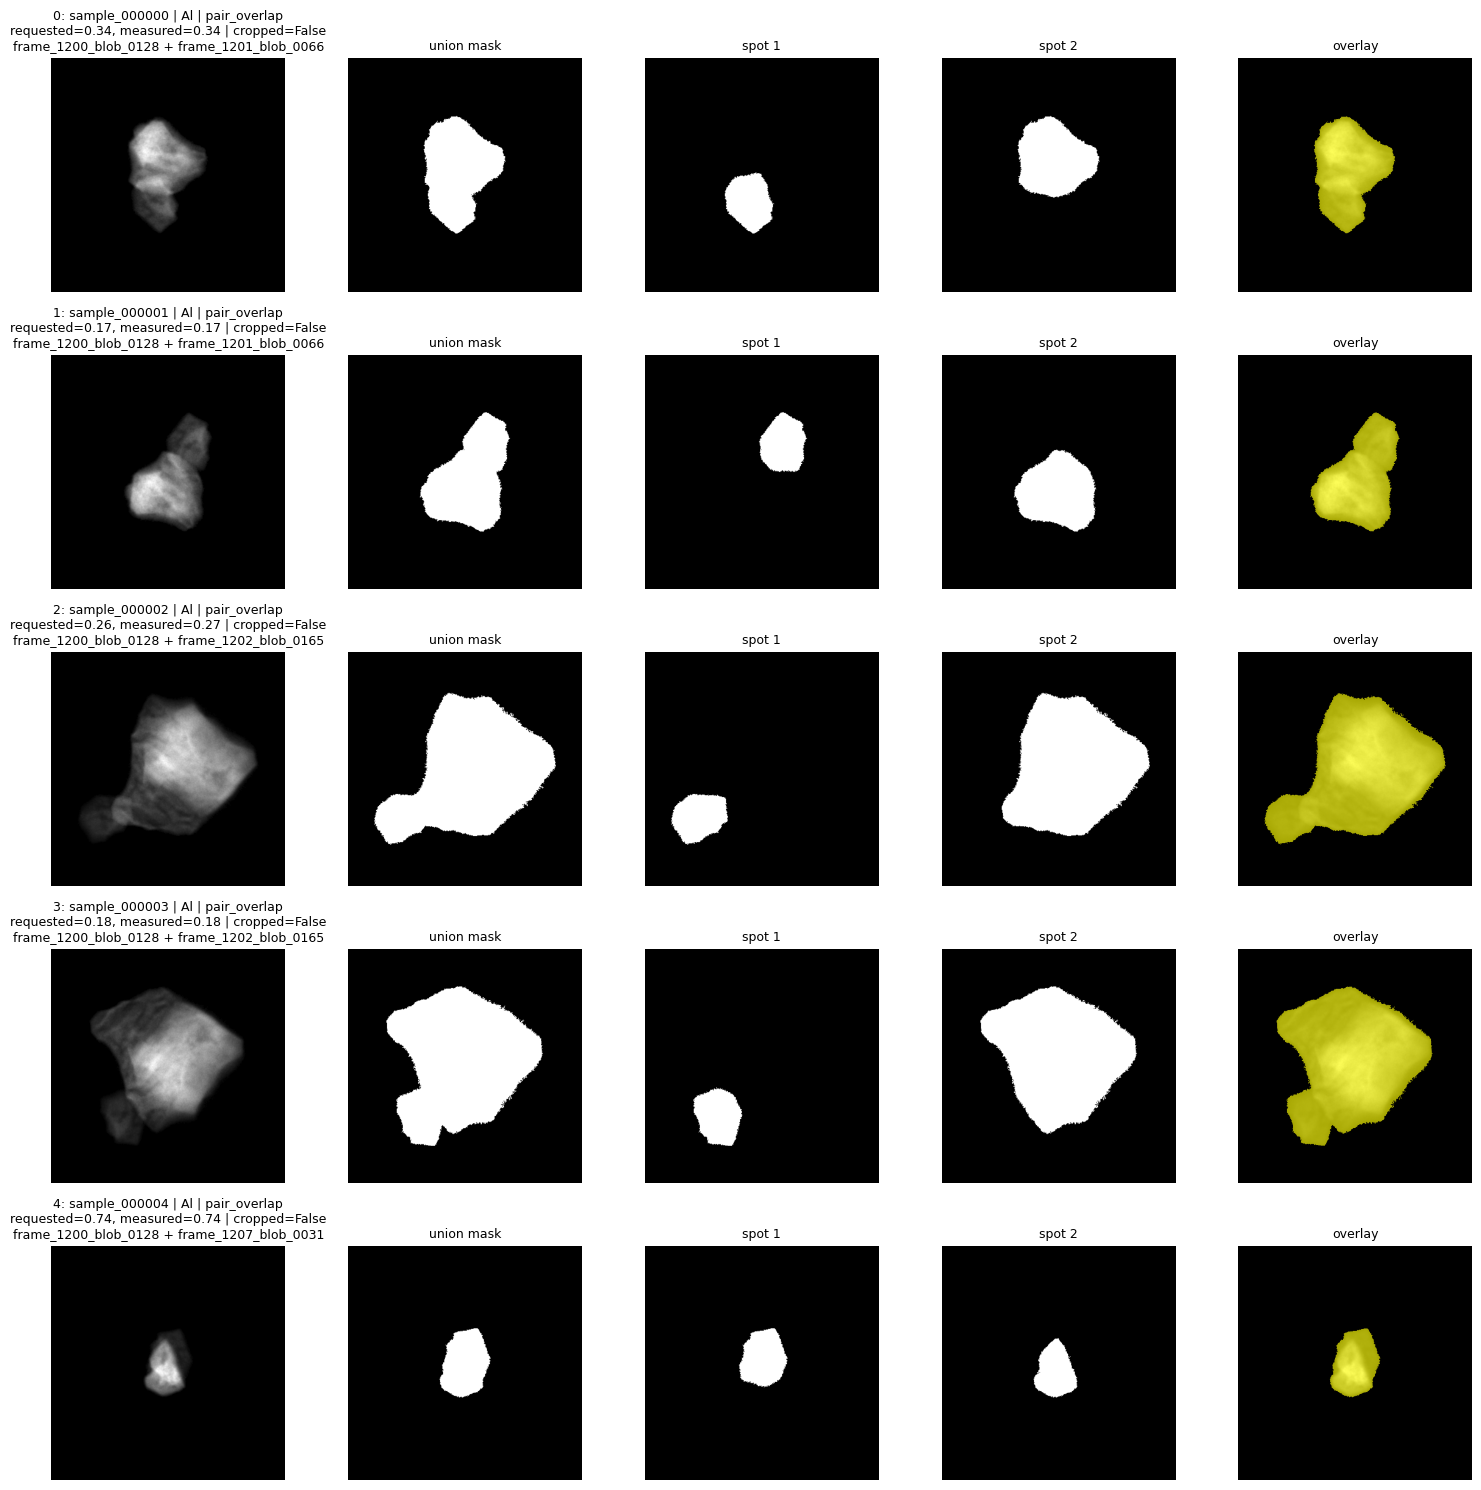

In [17]:
def summarize_augmented_archive(path=OUT_FILE):
    path = Path(path)
    if not path.exists():
        print(f"No augmented file found yet: {path}")
        return []

    with h5py.File(path, "r") as f:
        sample_names = sorted(k for k, v in f.items() if isinstance(v, h5py.Group))
        print(f"File: {path}")
        print(f"Samples: {len(sample_names)}")
        print("Attributes:")
        for key, value in sorted(f.attrs.items()):
            print(f"  {key}: {value}")

        per_dataset = {}
        per_kind = {}
        shapes = {}
        spot_mask_shapes = {}
        missing_spot_masks = 0
        cropped_to_fit = 0
        for name in sample_names:
            group = f[name]
            dataset = group.attrs.get("dataset", "<missing>")
            kind = group.attrs.get("kind", "<missing>")
            per_dataset[dataset] = per_dataset.get(dataset, 0) + 1
            per_kind[kind] = per_kind.get(kind, 0) + 1
            shapes[group["image"].shape] = shapes.get(group["image"].shape, 0) + 1
            if "spot_masks" in group:
                spot_mask_shapes[group["spot_masks"].shape] = spot_mask_shapes.get(group["spot_masks"].shape, 0) + 1
            else:
                missing_spot_masks += 1
            fixed = json.loads(group.attrs.get("fixed_patch", "{}"))
            cropped_to_fit += int(fixed.get("cropped_to_fit", False))

        print("By dataset:")
        for dataset, count in sorted(per_dataset.items()):
            print(f"  {dataset}: {count}")
        print("By kind:")
        for kind, count in sorted(per_kind.items()):
            print(f"  {kind}: {count}")
        print("Most common image shapes:")
        for shape, count in sorted(shapes.items(), key=lambda item: item[1], reverse=True)[:10]:
            print(f"  {shape}: {count}")
        print("Spot-mask storage:")
        if missing_spot_masks:
            print(f"  missing spot_masks: {missing_spot_masks} sample(s) - this is an older archive")
        for shape, count in sorted(spot_mask_shapes.items(), key=lambda item: item[1], reverse=True)[:10]:
            print(f"  {shape}: {count}")
        print(f"Cropped-to-fit samples: {cropped_to_fit}")

    return sample_names


def browse_augmented_archive(start=0, count=5, dataset=None, path=OUT_FILE):
    path = Path(path)
    if not path.exists():
        print(f"No augmented file found yet: {path}")
        return

    with h5py.File(path, "r") as f:
        sample_names = sorted(k for k, v in f.items() if isinstance(v, h5py.Group))
        if dataset is not None:
            sample_names = [name for name in sample_names if f[name].attrs.get("dataset") == dataset]

        selected = sample_names[start:start + count]
        if not selected:
            print("No samples found. Check start/count or dataset name.")
            return

        has_spot_masks = all("spot_masks" in f[name] for name in selected)
        ncols = 5 if has_spot_masks else 3
        fig, axes = plt.subplots(len(selected), ncols, figsize=(3 * ncols, 3 * len(selected)), squeeze=False)
        for row, name in enumerate(selected):
            group = f[name]
            image = group["image"][()]
            mask = group["mask"][()]
            spot_masks = group["spot_masks"][()] if "spot_masks" in group else None
            sample_dataset = group.attrs.get("dataset", "<missing>")
            kind = group.attrs.get("kind", "<missing>")
            requested = float(group.attrs.get("requested_overlap_fraction", 0.0))
            measured = float(group.attrs.get("measured_mask_overlap_fraction", 0.0))
            donors = json.loads(group.attrs.get("donor_spots", "[]"))
            donor_names = [donor.get("spot", "?").split("/")[-1] for donor in donors]
            donor_text = " + ".join(donor_names) if donor_names else "no donor metadata"
            fixed = json.loads(group.attrs.get("fixed_patch", "{}"))
            title = (
                f"{start + row}: {name} | {sample_dataset} | {kind}\n"
                f"requested={requested:.2f}, measured={measured:.2f} | cropped={fixed.get('cropped_to_fit', False)}\n"
                f"{donor_text}"
            )

            axes[row, 0].imshow(image, cmap="gray")
            axes[row, 0].set_title(title, fontsize=9)
            axes[row, 1].imshow(mask, cmap="gray", vmin=0, vmax=1)
            axes[row, 1].set_title("union mask", fontsize=9)
            col = 2
            if spot_masks is not None:
                axes[row, col].imshow(spot_masks[0], cmap="gray", vmin=0, vmax=1)
                axes[row, col].set_title("spot 1", fontsize=9)
                col += 1
                if spot_masks.shape[0] > 1:
                    axes[row, col].imshow(spot_masks[1], cmap="gray", vmin=0, vmax=1)
                else:
                    axes[row, col].imshow(np.zeros_like(mask), cmap="gray", vmin=0, vmax=1)
                axes[row, col].set_title("spot 2", fontsize=9)
                col += 1
            axes[row, col].imshow(image, cmap="gray")
            axes[row, col].imshow(np.ma.masked_where(mask == 0, mask), cmap="autumn", alpha=0.65, vmin=0, vmax=1)
            axes[row, col].set_title("overlay", fontsize=9)
            for ax in axes[row]:
                ax.axis("off")

        plt.tight_layout()
        print(f"Showing {len(selected)} saved sample(s), start={start}, next start={start + len(selected)}")


saved_sample_names = summarize_augmented_archive(OUT_FILE)
# Change start to browse the next batch: 0, 5, 10, ...
# Set dataset="Iron" or dataset="Al" if you only want one saved dataset.
browse_augmented_archive(start=0, count=5, dataset=None, path=OUT_FILE)
